# Ensemble Kalman Filters for Data Assimilation

This notebook compares stochastic EnKF and deterministic square-root ensemble filtering on the same two filtering testbeds. See Chapter 6, Section 6.3.5: Ensemble Kalman Filter.

## 1. Unified notation and two canonical testbeds

We use the standard hidden-state model
$$
\begin{aligned}
v_{j+1}^{\dagger} &= \Psi(v_j^{\dagger}) + \xi_j^{\dagger}, \quad
\xi_j^{\dagger} \sim \mathcal N(0,\Sigma), \\
y_{j+1}^{\dagger} &= h(v_{j+1}^{\dagger}) + \eta_{j+1}^{\dagger}, \quad
\eta_{j+1}^{\dagger} \sim \mathcal N(0,\Gamma).
\end{aligned}
$$
with observation history and filtering measures
$$
\begin{aligned}
&Y_j^{\dagger} = \{y_1^{\dagger},\dots,y_j^{\dagger}\}, \quad
\pi_j = \mathbb P(v_j^{\dagger}\mid Y_j^{\dagger}), \\
&\widehat\pi_{j+1} = \mathsf{P}\pi_j, \quad
\pi_{j+1} = \mathsf{A}_{j+1}\widehat\pi_{j+1}.
\end{aligned}
$$
and regularity assumptions $\Psi\in C^1(\mathbb R^d,\mathbb R^d),\ h\in C^1(\mathbb R^d,\mathbb R^k)$.


### 1.1 Test Dataset 1: Linear-Gaussian, d=2
$$
\begin{aligned}
v_{j+1} &= A v_j + \xi_j, \quad \xi_j \sim \mathcal N(0,\Sigma),\\
y_j &= H v_j + \eta_j, \quad \eta_j \sim \mathcal N(0,\Gamma).
\end{aligned}
$$
where
$$
A(\theta)=\begin{bmatrix}\cos\theta & -\sin\theta\\ \sin\theta & \cos\theta\end{bmatrix},
\qquad A^TA=I.
$$

Observation for this testbed is the first state component:
$$
h(v)=v_1,
\qquad H=\begin{bmatrix}1 & 0\end{bmatrix}.
$$

### 1.2 Test Dataset 2: Lorenz 63
$$
\begin{aligned}
\dot x &= \sigma(y-x), \\
\dot y &= x(\rho-z)-y, \\
\dot z &= xy-\beta z,
\end{aligned}
\qquad (\sigma,\rho,\beta)=\left(10,28,\frac{8}{3}\right).
$$
For Lorenz-63, we also observe the first state component only:
$$
h([x,y,z]^T)=x.
$$

### 1.3 DA Parameters and Numerical Details

#### Initial condition setup:

For the linear model, we take
$$
v_0 \sim \mathcal{N}(m_0, I),
$$
where the center can be a random initial point, e.g.
$$
m_0 \sim \mathcal{N}(0, I).
$$

For Lorenz-63, we use burn-in initialization: sample $m_0 \sim \mathcal{N}(0, I)$, run the model forward for many steps (100 steps here) to get $x_0$, and then set
$$
v_0 \sim \mathcal{N}(x_0, I).
$$
The burn-in trajectory is used only to choose the initial state; it is not included in the returned truth trajectory or in any plots.


#### Noise levels
$$
\Sigma = \sigma_v^2 I,
\qquad \sigma_v = 0.01,
$$
$$
\Gamma = \sigma_y^2 I,
\qquad \sigma_y = 1.
$$

#### Numerical integral:
For Lorenz 63:
$$
\Delta t = 0.15 \quad \text{(assimilation time step)},
$$
$$
dt = 0.03 \quad \text{(integration time step, RK4 scheme)}.
$$


## 2. Ensemble filters

As in particle approximations, at time step $j$ we approximate the filtering measure by an empirical measure with $N$ particles (ensemble members):
$$
\pi_j \approx \pi_j^N = \frac{1}{N}\sum_{n=1}^N \delta_{v_j^{(n)}}.
$$
After forecast, we similarly have
$$
\widehat\pi_{j+1}^N = \frac{1}{N}\sum_{n=1}^N \delta_{\widehat v_{j+1}^{(n)}}.
$$

The key reason to use ensemble filters is that in high dimensions we avoid propagating full covariance matrices directly. Instead, we use ensemble statistics:
$$
\bar v_{j+1}^f = \frac{1}{N}\sum_{n=1}^N \widehat v_{j+1}^{(n)}, \qquad
\bar y_{j+1}^f = \frac{1}{N}\sum_{n=1}^N h\!\left(\widehat v_{j+1}^{(n)}\right),|
$$
$$
\widehat C_{j+1}^{vy} \approx \frac{1}{N-1}\sum_{n=1}^N
\left(\widehat v_{j+1}^{(n)}-\bar v_{j+1}^f\right)
\left(h(\widehat v_{j+1}^{(n)})-\bar y_{j+1}^f\right)^T,
$$
$$
\widehat C_{j+1}^{yy} \approx \frac{1}{N-1}\sum_{n=1}^N
\left(h(\widehat v_{j+1}^{(n)})-\bar y_{j+1}^f\right)
\left(h(\widehat v_{j+1}^{(n)})-\bar y_{j+1}^f\right)^T + \Gamma.
$$
Then the ensemble Kalman gain is
$$
K_{j+1}=\widehat C_{j+1}^{vy}\left(\widehat C_{j+1}^{yy}\right)^{-1}.
$$

### 2.1 Stochastic EnKF (Perturbed Observations)

Given forecast members $\{\widehat v_{j+1}^{(n)}\}_{n=1}^N$ and observation $y_{j+1}^{\dagger}$:

1. Compute $Y_{j+1}^{(n)}=h\!\left(\widehat v_{j+1}^{(n)}\right)$ and estimate $K_{j+1}$ from ensemble covariances.
2. Draw independent perturbations
$$
\eta_{j+1}^{(n)}\sim\mathcal N(0,\Gamma),\quad n=1,\dots,N.
$$
3. Update each ensemble member with a perturbed innovation:
$$
v_{j+1}^{(n),a}=\widehat v_{j+1}^{(n)}+K_{j+1}\Big(y_{j+1}^{\dagger}+\eta_{j+1}^{(n)}-Y_{j+1}^{(n)}\Big).
$$

This stochastic update gives the correct analysis covariance in expectation, but introduces additional Monte Carlo noise through $\eta_{j+1}^{(n)}$.

### 2.2 EnSRF (Deterministic Square-Root Analysis)

EnSRF removes the observation perturbation and updates mean/anomalies deterministically.

Let forecast mean and anomalies be
$$
\bar v_{j+1}^f=\frac{1}{N}\sum_{n=1}^N\widehat v_{j+1}^{(n)},\qquad
a_{j+1}^{(n),f}=\widehat v_{j+1}^{(n)}-\bar v_{j+1}^f.
$$
For the serial (one-observation-at-a-time) form used in code, for each observed component $\ell$:

1. Forecast observation anomalies:
$$
d_{\ell}^{(n)} = h_{\ell}\!\left(\widehat v_{j+1}^{(n)}\right)-\bar y_{j+1,\ell}^f.
$$
2. Scalar covariances:
$$
p_{yy,\ell}=\frac{1}{N-1}\sum_{n=1}^N (d_{\ell}^{(n)})^2 + \gamma_{\ell},
\qquad
p_{xy,\ell}=\frac{1}{N-1}\sum_{n=1}^N a_{j+1}^{(n),f}d_{\ell}^{(n)}.
$$
3. Mean update:
$$
K_{\ell}=\frac{p_{xy,\ell}}{p_{yy,\ell}},\qquad
\bar v_{j+1}^a \leftarrow \bar v_{j+1}^a + K_{\ell}\big(y_{j+1,\ell}^{\dagger}-\bar y_{j+1,\ell}^f\big).
$$
4. Anomaly square-root update:
$$
\alpha_{\ell}=\frac{1}{1+\sqrt{\gamma_{\ell}/p_{yy,\ell}}},
\qquad
\widetilde K_{\ell}=\alpha_{\ell}K_{\ell},
$$
$$
a_{j+1}^{(n),a} \leftarrow a_{j+1}^{(n),f} - \widetilde K_{\ell} d_{\ell}^{(n)}.
$$
5. Recompose members: $v_{j+1}^{(n),a}=\bar v_{j+1}^a+a_{j+1}^{(n),a}$.

Compared with particle filters, ensemble members remain **equally weighted** throughout. There is no importance-weight degeneracy/resampling loop; instead, the update is driven by global ensemble properties (means, covariances, anomalies).

Below we implement two ensemble filters on the same two testbeds (Linear-Gaussian and Lorenz-63):
- Stochastic EnKF
- Ensemble Square-Root Filter (EnSRF)

Both examples include a **post-analysis inflation** factor $r_{\text{infl}}$ (default $1.0$, i.e. no inflation):
$$
v_{j+1}^{(n),a} \leftarrow \bar v_{j+1}^{a} + r_{\text{infl}}\Big(v_{j+1}^{(n),a}-\bar v_{j+1}^{a}\Big),\qquad n=1,\dots,N.
$$


## 3. Linear Gaussian ensemble experiment

**Parameter exploration.**

- `ensemble_size`: Larger ensembles give more stable sample covariances and usually reduce sampling noise.
- `inflation`: Values above one spread the analysis ensemble after each update; too much inflation can overreact in this low-dimensional linear example.
- `observation_noise_std`: Increasing this noise weakens the data correction and makes forecast covariance more influential.
- `use_true_initialization`: Turning this off tests how rapidly ensemble updates recover from an initial offset.

**Recommended test combinations.** Keep unspecified controls at their displayed defaults.

| `ensemble_size` | `inflation` | `observation_noise_std` | What to compare |
|---:|---:|---:|---|
| 10 | 1.00 | 1.0 | Small ensemble: visibly noisy sample covariance. |
| 80 | 1.00 | 1.0 | Large ensemble: much steadier covariance estimates. |
| 20 | 1.25 | 1.0 | Strong inflation: useful stress test for over-spreading. |


Effective parameters:
  steps: 80
  theta: 0.3
  dynamics_noise_std: 0.01
  observation_noise_std: 1.0
  ensemble_size: 10
  inflation: 1.0
  use_true_initialization: True
  seed: 42

RMSE by method:
  Stochastic EnKF: 0.280
  EnSRF: 0.252


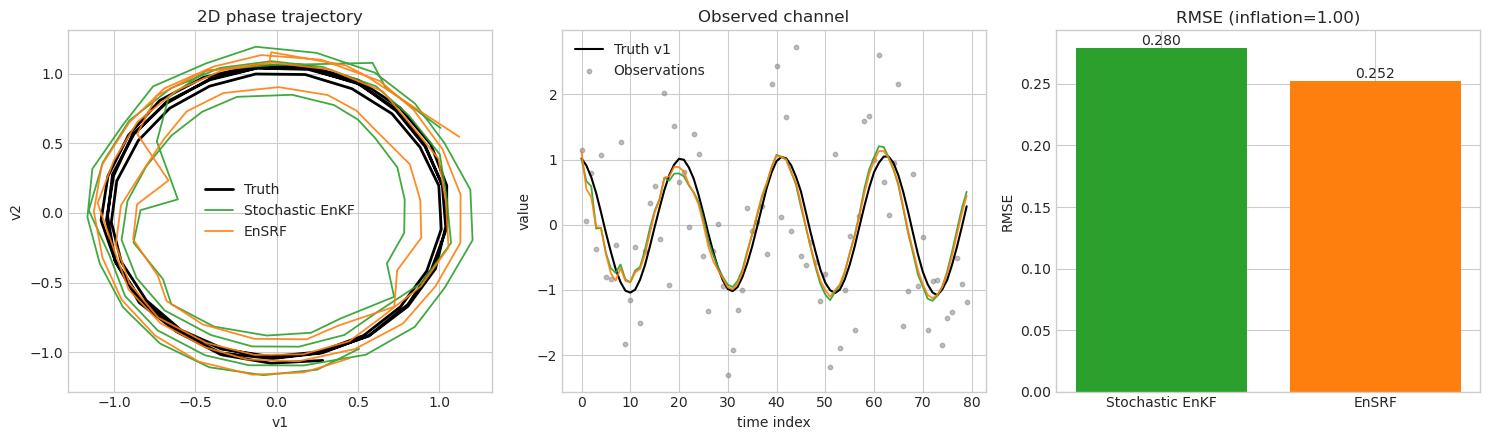

In [1]:
#@title Linear Gaussian ensemble-filter comparison
try:
    import torch
except ImportError:
    torch = None
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
np.set_printoptions(precision=4, suppress=True)

TORCH_AVAILABLE = torch is not None
TORCH_GPU_AVAILABLE = bool(TORCH_AVAILABLE and torch.cuda.is_available())
TORCH_DEVICE = torch.device("cuda") if TORCH_GPU_AVAILABLE else (torch.device("cpu") if TORCH_AVAILABLE else None)
TORCH_DTYPE = torch.float64 if TORCH_AVAILABLE else None


def as_torch(x, device=None, dtype=None):
    if not TORCH_AVAILABLE:
        raise RuntimeError("PyTorch is not available in this environment.")
    if device is None:
        device = TORCH_DEVICE
    if dtype is None:
        dtype = TORCH_DTYPE
    return torch.as_tensor(x, device=device, dtype=dtype)


def symmetrize_torch(M):
    return 0.5 * (M + M.T)


def mvn_sample_torch(mean, cov, size=None, generator=None, eps=1e-9):
    mean = as_torch(mean)
    cov = as_torch(cov, device=mean.device, dtype=mean.dtype)
    cov = symmetrize_torch(cov)
    w, V = torch.linalg.eigh(cov)
    w = torch.clamp(w, min=eps)
    sqrt_cov = (V * torch.sqrt(w)) @ V.T
    d = mean.shape[0]
    if size is None:
        z = torch.randn(d, device=mean.device, dtype=mean.dtype, generator=generator)
        return mean + sqrt_cov @ z
    z = torch.randn((size, d), device=mean.device, dtype=mean.dtype, generator=generator)
    return z @ sqrt_cov.T + mean


def gaussian_logpdf_torch(x, mean, cov):
    x = as_torch(x).reshape(-1)
    mean = as_torch(mean, device=x.device, dtype=x.dtype).reshape(-1)
    cov = as_torch(cov, device=x.device, dtype=x.dtype)
    cov = symmetrize_torch(cov)
    d = x.shape[0]
    xc = x - mean
    sign, logdet = torch.linalg.slogdet(cov)
    if sign.item() <= 0:
        cov = cov + 1e-9 * torch.eye(cov.shape[0], device=cov.device, dtype=cov.dtype)
        _, logdet = torch.linalg.slogdet(cov)
    quad = xc @ torch.linalg.pinv(cov) @ xc
    const = torch.log(torch.tensor(2.0 * np.pi, device=x.device, dtype=x.dtype))
    return -0.5 * (d * const + logdet + quad)


def gaussian_logpdf_batch_torch(x, means, cov):
    means = as_torch(means)
    x = as_torch(x, device=means.device, dtype=means.dtype).reshape(1, -1)
    cov = as_torch(cov, device=means.device, dtype=means.dtype)
    cov = symmetrize_torch(cov)

    d = means.shape[1]
    xc = means - x
    sign, logdet = torch.linalg.slogdet(cov)
    if sign.item() <= 0:
        cov = cov + 1e-9 * torch.eye(cov.shape[0], device=cov.device, dtype=cov.dtype)
        _, logdet = torch.linalg.slogdet(cov)
    cov_inv = torch.linalg.pinv(cov)
    quad = torch.sum((xc @ cov_inv) * xc, dim=1)
    const = torch.log(torch.tensor(2.0 * np.pi, device=means.device, dtype=means.dtype))
    return -0.5 * (d * const + logdet + quad)


def normalize_logweights_torch(logw):
    m = torch.max(logw)
    w = torch.exp(logw - m)
    s = torch.sum(w)
    if (not torch.isfinite(s).item()) or (s.item() <= 0):
        return torch.ones_like(logw) / logw.numel()
    return w / s


def systematic_resample_torch(weights, generator=None):
    n = weights.numel()
    u0 = torch.rand((), device=weights.device, dtype=weights.dtype, generator=generator)
    u = (u0 + torch.arange(n, device=weights.device, dtype=weights.dtype)) / n
    cdf = torch.cumsum(weights, dim=0)
    idx = torch.searchsorted(cdf, u, right=True)
    return torch.clamp(idx, 0, n - 1).long()


def lorenz63_rhs_torch(x, sigma=10.0, rho=28.0, beta=8.0 / 3.0):
    xx = x[..., 0]
    yy = x[..., 1]
    zz = x[..., 2]
    return torch.stack([
        sigma * (yy - xx),
        xx * (rho - zz) - yy,
        xx * yy - beta * zz,
    ], dim=-1)


def lorenz63_step_torch(x, dt=0.03):
    k1 = lorenz63_rhs_torch(x)
    k2 = lorenz63_rhs_torch(x + 0.5 * dt * k1)
    k3 = lorenz63_rhs_torch(x + 0.5 * dt * k2)
    k4 = lorenz63_rhs_torch(x + dt * k3)
    return x + (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)



def symmetrize(M):
    return 0.5 * (M + M.T)


def sqrtm_psd(M, eps=1e-12):
    w, V = np.linalg.eigh(symmetrize(M))
    w = np.clip(w, eps, None)
    return (V * np.sqrt(w)) @ V.T


def invsqrtm_psd(M, eps=1e-12):
    w, V = np.linalg.eigh(symmetrize(M))
    w = np.clip(w, eps, None)
    return (V * (1.0 / np.sqrt(w))) @ V.T


def gaussian_logpdf(x, mean, cov):
    x = np.atleast_1d(x)
    mean = np.atleast_1d(mean)
    cov = np.atleast_2d(cov)
    d = x.shape[0]
    xc = x - mean
    sign, logdet = np.linalg.slogdet(cov)
    if sign <= 0:
        cov = cov + 1e-9 * np.eye(cov.shape[0])
        sign, logdet = np.linalg.slogdet(cov)
    quad = xc @ np.linalg.pinv(cov) @ xc
    return -0.5 * (d * np.log(2.0 * np.pi) + logdet + quad)


def normalize_logweights(logw):
    m = np.max(logw)
    w = np.exp(logw - m)
    s = np.sum(w)
    if (not np.isfinite(s)) or s <= 0:
        return np.ones_like(logw) / len(logw)
    return w / s


def systematic_resample(weights, rng):
    n = len(weights)
    u = (rng.random() + np.arange(n)) / n
    cdf = np.cumsum(weights)
    idx = np.searchsorted(cdf, u, side="right")
    return np.clip(idx, 0, n - 1)


def make_rotation(theta):
    c, s = np.cos(theta), np.sin(theta)
    return np.array([[c, -s], [s, c]])


def sample_linear_initial(rng, d=2):
    m0 = rng.multivariate_normal(np.zeros(d), np.eye(d))
    v0 = rng.multivariate_normal(m0, np.eye(d))
    return v0, m0


def simulate_linear_gaussian_2d(T=80, theta=0.3, sigma_v=0.01, sigma_y=1.0, seed=0):
    rng = np.random.default_rng(seed)
    A = make_rotation(theta)
    H = np.array([[1.0, 0.0]])
    Sigma = (sigma_v ** 2) * np.eye(2)
    Gamma = np.array([[sigma_y ** 2]])

    truth = np.zeros((T, 2))
    obs = np.zeros((T, 1))

    v, _ = sample_linear_initial(rng, d=2)
    for k in range(T):
        v = A @ v + rng.multivariate_normal(np.zeros(2), Sigma)
        y = H @ v + rng.multivariate_normal(np.zeros(1), Gamma)
        truth[k] = v
        obs[k] = y

    return truth, obs, A, H, Sigma, Gamma


def lorenz63_rhs(x, sigma=10.0, rho=28.0, beta=8.0 / 3.0):
    xx, yy, zz = x
    return np.array([
        sigma * (yy - xx),
        xx * (rho - zz) - yy,
        xx * yy - beta * zz,
    ])


def lorenz63_step(x, dt=0.03):
    k1 = lorenz63_rhs(x)
    k2 = lorenz63_rhs(x + 0.5 * dt * k1)
    k3 = lorenz63_rhs(x + 0.5 * dt * k2)
    k4 = lorenz63_rhs(x + dt * k3)
    return x + (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)


def lorenz63_burnin_initial(rng, dt=0.03, burn_steps=100):
    m0 = rng.multivariate_normal(np.zeros(3), np.eye(3))
    x = m0.copy()
    for _ in range(burn_steps):
        x = lorenz63_step(x, dt)
    x0 = x.copy()
    v0 = rng.multivariate_normal(x0, np.eye(3))
    return v0, m0, x0


def simulate_lorenz63(T=10.0, dt=0.03, Delta_t=0.15, sigma_v=0.01, sigma_y=1.0, burn_steps=100, seed=0):
    rng = np.random.default_rng(seed)
    n_steps = max(int(T / dt), 1)

    truth = np.zeros((n_steps, 3))
    x, _, _ = lorenz63_burnin_initial(rng, dt=dt, burn_steps=burn_steps)

    for t in range(n_steps):
        x = lorenz63_step(x, dt)
        if sigma_v > 0:
            x = x + rng.normal(0.0, sigma_v, size=3)
        truth[t] = x

    obs_gap = max(int(round(Delta_t / dt)), 1)
    obs_idx = [0]  # Observe first dimension only
    obs_times = np.arange(obs_gap, n_steps, obs_gap)
    Gamma = (sigma_y ** 2) * np.eye(len(obs_idx))
    obs = truth[obs_times][:, obs_idx] + rng.multivariate_normal(np.zeros(len(obs_idx)), Gamma, size=len(obs_times))

    return truth, obs, obs_times, obs_idx


def analysis_enkf_stochastic(Xf, y_obs, h_func, Gamma, rng):
    N = Xf.shape[0]
    Yf = np.array([h_func(x) for x in Xf])

    xbar = Xf.mean(axis=0)
    ybar = Yf.mean(axis=0)

    Xp = Xf - xbar
    Yp = Yf - ybar

    Pxy = (Xp.T @ Yp) / max(N - 1, 1)
    Pyy = (Yp.T @ Yp) / max(N - 1, 1) + Gamma

    K = Pxy @ np.linalg.pinv(Pyy)
    pert = rng.multivariate_normal(np.zeros(len(y_obs)), Gamma, size=N)

    Xa = Xf + (y_obs + pert - Yf) @ K.T
    return Xa


def analysis_ensrf(Xf, y_obs, h_func, gamma_diag):
    # Serial square-root update for (approximately) diagonal observation error covariance.
    X = Xf.copy()
    m_obs = len(y_obs)

    for ell in range(m_obs):
        Y = np.array([h_func(x) for x in X])
        y_f = Y[:, ell]

        x_mean = X.mean(axis=0)
        A = X - x_mean
        y_mean = np.mean(y_f)
        dy = y_f - y_mean

        r = max(float(gamma_diag[ell]), 1e-12)
        p_yy = (dy @ dy) / max(len(dy) - 1, 1) + r
        p_xy = (A.T @ dy) / max(len(dy) - 1, 1)

        K = p_xy / p_yy
        x_mean = x_mean + K * (y_obs[ell] - y_mean)

        alpha = 1.0 / (1.0 + np.sqrt(r / p_yy))
        K_tilde = alpha * K
        A = A - np.outer(dy, K_tilde)

        X = x_mean + A

    return X


def post_analysis_inflate(Xa, infl_rate):
    if np.isclose(infl_rate, 1.0):
        return Xa
    xbar = Xa.mean(axis=0, keepdims=True)
    return xbar + infl_rate * (Xa - xbar)


def analysis_enkf_stochastic_torch(Xf, y_obs, H, Gamma):
    N = Xf.shape[0]
    Yf = Xf @ H.T

    xbar = Xf.mean(dim=0)
    ybar = Yf.mean(dim=0)

    Xp = Xf - xbar
    Yp = Yf - ybar

    Pxy = (Xp.T @ Yp) / max(N - 1, 1)
    Pyy = (Yp.T @ Yp) / max(N - 1, 1) + Gamma

    K = Pxy @ torch.linalg.pinv(Pyy)
    pert = mvn_sample_torch(
        torch.zeros(y_obs.shape[0], device=Xf.device, dtype=Xf.dtype),
        Gamma,
        size=N,
    )
    Xa = Xf + (y_obs.unsqueeze(0) + pert - Yf) @ K.T
    return Xa


def analysis_ensrf_torch(Xf, y_obs, H, gamma_diag):
    X = Xf.clone()
    m_obs = y_obs.shape[0]

    for ell in range(m_obs):
        y_f = X @ H[ell]

        x_mean = X.mean(dim=0)
        A = X - x_mean
        y_mean = torch.mean(y_f)
        dy = y_f - y_mean

        r = torch.clamp(gamma_diag[ell], min=1e-12)
        p_yy = (dy @ dy) / max(len(dy) - 1, 1) + r
        p_xy = (A.T @ dy) / max(len(dy) - 1, 1)

        K = p_xy / p_yy
        x_mean = x_mean + K * (y_obs[ell] - y_mean)

        alpha = 1.0 / (1.0 + torch.sqrt(r / p_yy))
        K_tilde = alpha * K
        A = A - torch.outer(dy, K_tilde)
        X = x_mean + A

    return X


def post_analysis_inflate_torch(Xa, infl_rate):
    if np.isclose(infl_rate, 1.0):
        return Xa
    xbar = Xa.mean(dim=0, keepdim=True)
    return xbar + infl_rate * (Xa - xbar)


def run_ensemble_linear_torch(
    obs,
    A,
    H,
    Sigma,
    Gamma,
    N,
    method,
    use_true_init,
    truth_x0,
    inflation,
    seed,
    progress_bar=None,
):
    device = torch.device("cuda")
    torch.manual_seed(int(seed))
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(int(seed))

    obs_t = as_torch(obs, device=device, dtype=TORCH_DTYPE)
    A_t = as_torch(A, device=device, dtype=TORCH_DTYPE)
    H_t = as_torch(H, device=device, dtype=TORCH_DTYPE)
    Sigma_t = as_torch(Sigma, device=device, dtype=TORCH_DTYPE)
    Gamma_t = as_torch(Gamma, device=device, dtype=TORCH_DTYPE)
    truth_x0_t = as_torch(truth_x0, device=device, dtype=TORCH_DTYPE)

    T = obs_t.shape[0]
    d = A_t.shape[0]

    if use_true_init:
        X = mvn_sample_torch(truth_x0_t, torch.eye(d, device=device, dtype=TORCH_DTYPE), size=N)
    else:
        offset = torch.normal(mean=0.0, std=0.5, size=(d,), device=device, dtype=TORCH_DTYPE)
        X = mvn_sample_torch(truth_x0_t + offset, torch.eye(d, device=device, dtype=TORCH_DTYPE), size=N)

    est = torch.zeros((T, d), device=device, dtype=TORCH_DTYPE)
    zero_d = torch.zeros(d, device=device, dtype=TORCH_DTYPE)

    for k in range(T):
        X = X @ A_t.T + mvn_sample_torch(zero_d, Sigma_t, size=N)

        y = obs_t[k].reshape(-1)
        if method == "enkf":
            X = analysis_enkf_stochastic_torch(X, y, H_t, Gamma_t)
        elif method == "ensrf":
            X = analysis_ensrf_torch(X, y, H_t, torch.diag(Gamma_t))
        else:
            raise ValueError(f"Unknown ensemble method: {method}")

        X = post_analysis_inflate_torch(X, inflation)
        est[k] = X.mean(dim=0)

        if progress_bar:
            progress_bar.value += 1

    return est.detach().cpu().numpy()


def run_ensemble_lorenz_torch(
    obs,
    obs_times,
    obs_idx,
    dt,
    sigma_v,
    sigma_y,
    N,
    method,
    use_true_init,
    truth_x0,
    inflation,
    seed,
    progress_bar=None,
):
    device = torch.device("cuda")
    torch.manual_seed(int(seed))
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(int(seed))

    T_obs = len(obs)
    d = 3

    H_t = torch.zeros((len(obs_idx), d), device=device, dtype=TORCH_DTYPE)
    for r, c in enumerate(obs_idx):
        H_t[r, c] = 1.0

    Gamma_t = (sigma_y ** 2) * torch.eye(len(obs_idx), device=device, dtype=TORCH_DTYPE)
    truth_x0_t = as_torch(truth_x0, device=device, dtype=TORCH_DTYPE)

    if use_true_init:
        X = mvn_sample_torch(truth_x0_t, torch.eye(d, device=device, dtype=TORCH_DTYPE), size=N)
    else:
        offset = torch.normal(mean=0.0, std=2.0, size=(d,), device=device, dtype=TORCH_DTYPE)
        X = mvn_sample_torch(truth_x0_t + offset, torch.eye(d, device=device, dtype=TORCH_DTYPE), size=N)

    obs_t = as_torch(obs, device=device, dtype=TORCH_DTYPE)
    est = torch.zeros((T_obs, d), device=device, dtype=TORCH_DTYPE)
    current_time_step = 0

    for k in range(T_obs):
        target_time_step = int(obs_times[k])
        steps_to_sim = max(target_time_step - current_time_step, 0)

        for _ in range(steps_to_sim):
            X = lorenz63_step_torch(X, dt)
            if sigma_v > 0:
                X = X + sigma_v * torch.randn_like(X)

        y = obs_t[k].reshape(-1)
        if method == "enkf":
            X = analysis_enkf_stochastic_torch(X, y, H_t, Gamma_t)
        elif method == "ensrf":
            X = analysis_ensrf_torch(X, y, H_t, torch.diag(Gamma_t))
        else:
            raise ValueError(f"Unknown ensemble method: {method}")

        X = post_analysis_inflate_torch(X, inflation)
        est[k] = X.mean(dim=0)
        current_time_step = target_time_step

        if progress_bar:
            progress_bar.value += 1

    return est.detach().cpu().numpy()


def run_ensemble_linear(
    obs,
    A,
    H,
    Sigma,
    Gamma,
    N,
    method,
    use_true_init,
    truth_x0,
    inflation,
    seed,
    progress_bar=None,
):
    if TORCH_GPU_AVAILABLE:
        return run_ensemble_linear_torch(
            obs,
            A,
            H,
            Sigma,
            Gamma,
            N,
            method,
            use_true_init,
            truth_x0,
            inflation,
            seed,
            progress_bar=progress_bar,
        )

    rng = np.random.default_rng(seed)
    T = len(obs)
    d = A.shape[0]

    if use_true_init:
        X = rng.multivariate_normal(truth_x0, np.eye(d), size=N)
    else:
        offset = rng.normal(0.0, 0.5, size=d)
        X = rng.multivariate_normal(truth_x0 + offset, np.eye(d), size=N)

    est = np.zeros((T, d))

    def h_lin(x):
        return (H @ x).reshape(-1)

    for k in range(T):
        # Forecast
        X = X @ A.T + rng.multivariate_normal(np.zeros(d), Sigma, size=N)

        # Analysis
        y = obs[k].reshape(-1)
        if method == "enkf":
            X = analysis_enkf_stochastic(X, y, h_lin, Gamma, rng)
        elif method == "ensrf":
            X = analysis_ensrf(X, y, h_lin, np.diag(Gamma))
        else:
            raise ValueError(f"Unknown ensemble method: {method}")

        # Post-analysis inflation
        X = post_analysis_inflate(X, inflation)

        est[k] = X.mean(axis=0)

        if progress_bar:
            progress_bar.value += 1

    return est


def run_ensemble_lorenz(
    obs,
    obs_times,
    obs_idx,
    dt,
    sigma_v,
    sigma_y,
    N,
    method,
    use_true_init,
    truth_x0,
    inflation,
    seed,
    progress_bar=None,
):
    if TORCH_GPU_AVAILABLE:
        return run_ensemble_lorenz_torch(
            obs,
            obs_times,
            obs_idx,
            dt,
            sigma_v,
            sigma_y,
            N,
            method,
            use_true_init,
            truth_x0,
            inflation,
            seed,
            progress_bar=progress_bar,
        )

    rng = np.random.default_rng(seed)
    T_obs = len(obs)
    d = 3

    H = np.zeros((len(obs_idx), d))
    for r, c in enumerate(obs_idx):
        H[r, c] = 1.0

    Gamma = (sigma_y ** 2) * np.eye(len(obs_idx))

    if use_true_init:
        X = rng.multivariate_normal(truth_x0, np.eye(d), size=N)
    else:
        offset = rng.normal(0.0, 2.0, size=d)
        X = rng.multivariate_normal(truth_x0 + offset, np.eye(d), size=N)

    est = np.zeros((T_obs, d))
    current_time_step = 0

    def h_l63(x):
        return x[obs_idx]

    for k in range(T_obs):
        target_time_step = obs_times[k]
        steps_to_sim = target_time_step - current_time_step

        # Forecast
        for i in range(N):
            temp = X[i]
            for _ in range(steps_to_sim):
                temp = lorenz63_step(temp, dt)
                if sigma_v > 0:
                    temp += rng.normal(0.0, sigma_v, size=d)
            X[i] = temp

        # Analysis
        y = np.atleast_1d(obs[k])
        if method == "enkf":
            X = analysis_enkf_stochastic(X, y, h_l63, Gamma, rng)
        elif method == "ensrf":
            X = analysis_ensrf(X, y, h_l63, np.diag(Gamma))
        else:
            raise ValueError(f"Unknown ensemble method: {method}")

        # Post-analysis inflation
        X = post_analysis_inflate(X, inflation)

        est[k] = X.mean(axis=0)
        current_time_step = target_time_step

        if progress_bar:
            progress_bar.value += 1

    return est

DEFAULT_PARAMETERS = {
    "linear_ensemble_filter": {
        "steps": 80,
        "theta": 0.3,
        "dynamics_noise_std": 0.01,
        "observation_noise_std": 1.0,
        "ensemble_size": 10,
        "inflation": 1.0,
        "use_true_initialization": True,
        "seed": 42,
    },
}

use_default = False #@param {type:"boolean"}
ensemble_size = 10 #@param {type:"slider", min:5, max:100, step:5}
inflation = 1.0 #@param {type:"slider", min:1.0, max:1.3, step:0.01}
observation_noise_std = 1.0 #@param {type:"slider", min:0.2, max:3.0, step:0.1}
use_true_initialization = True #@param {type:"boolean"}

params = DEFAULT_PARAMETERS["linear_ensemble_filter"].copy()
if not use_default:
    params.update({
        "ensemble_size": int(ensemble_size),
        "inflation": float(inflation),
        "observation_noise_std": float(observation_noise_std),
        "use_true_initialization": bool(use_true_initialization),
    })

truth, obs, A, H, Sigma, Gamma = simulate_linear_gaussian_2d(
    T=params["steps"],
    theta=params["theta"],
    sigma_v=params["dynamics_noise_std"],
    sigma_y=params["observation_noise_std"],
    seed=params["seed"],
)
methods = [
    ("Stochastic EnKF", "enkf", "tab:green"),
    ("EnSRF", "ensrf", "tab:orange"),
]

results = []
rmses = []
for name, method_code, color in methods:
    est = run_ensemble_linear(
        obs,
        A,
        H,
        Sigma,
        Gamma,
        params["ensemble_size"],
        method_code,
        params["use_true_initialization"],
        truth[0],
        params["inflation"],
        seed=params["seed"] + 10,
    )
    rmse = np.sqrt(np.mean(np.sum((est - truth) ** 2, axis=1)))
    results.append((name, est, color))
    rmses.append(rmse)

print("Effective parameters:")
for key, value in params.items():
    print(f"  {key}: {value}")
print("\nRMSE by method:")
for (name, _, _), rmse in zip(results, rmses):
    print(f"  {name}: {rmse:.3f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
ax = axes[0]
ax.plot(truth[:, 0], truth[:, 1], "k-", lw=2, label="Truth")
for name, est, color in results:
    ax.plot(est[:, 0], est[:, 1], color=color, lw=1.3, alpha=0.9, label=name)
ax.set_title("2D phase trajectory")
ax.set_xlabel("v1")
ax.set_ylabel("v2")
ax.legend()

ax = axes[1]
t = np.arange(params["steps"])
ax.plot(t, truth[:, 0], "k-", label="Truth v1")
ax.scatter(t, obs[:, 0], c="gray", s=10, alpha=0.5, label="Observations")
for name, est, color in results:
    ax.plot(t, est[:, 0], color=color, lw=1.3, alpha=0.9)
ax.set_title("Observed channel")
ax.set_xlabel("time index")
ax.set_ylabel("value")
ax.legend()

ax = axes[2]
bars = ax.bar([name for name, _, _ in results], rmses, color=[color for _, _, color in results])
ax.set_title(f"RMSE (inflation={params['inflation']:.2f})")
ax.set_ylabel("RMSE")
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height, f"{height:.3f}", ha="center", va="bottom")

fig.tight_layout()
plt.show()


## 4. Lorenz-63 ensemble experiment

The Lorenz-63 burn-in trajectory is discarded before plotting; all displayed trajectories start after burn-in.

**Parameter exploration.**

- `ensemble_size`: Compare a very small ensemble (`10`) with a larger ensemble (`50`) to see how sample-covariance noise changes the analysis.
- `inflation`: Use `1.05` as a mild inflation setting. This value gives a clear contrast with no inflation for `ensemble_size = 10`, while larger inflation values can over-spread the ensemble.
- `total_time`: Use `30` for the recommended comparisons so the chaotic dynamics have enough time to reveal differences between settings.
- `use_true_initialization`: Turning this off stresses the filter with a larger initial mismatch.

**Recommended test combinations.** Keep unspecified controls at their displayed defaults.

| `ensemble_size` | `inflation` | `total_time` | What to compare |
|---:|---:|---:|---|
| 10 | 1.00 | 30.0 | Small ensemble without inflation. |
| 10 | 1.05 | 30.0 | Same small ensemble with mild inflation; compare whether the added spread improves tracking. |
| 50 | 1.00 | 30.0 | Larger ensemble without inflation. |
| 50 | 1.05 | 30.0 | Larger ensemble with the same mild inflation setting. |


Effective parameters:
  total_time: 30.0
  dt: 0.03
  assimilation_time_step: 0.15
  dynamics_noise_std: 0.01
  observation_noise_std: 1.0
  ensemble_size: 10
  inflation: 1.0
  use_true_initialization: True
  burn_steps: 100
  seed: 99

RMSE at observation times:
  Stochastic EnKF: 2.080
  EnSRF: 1.667


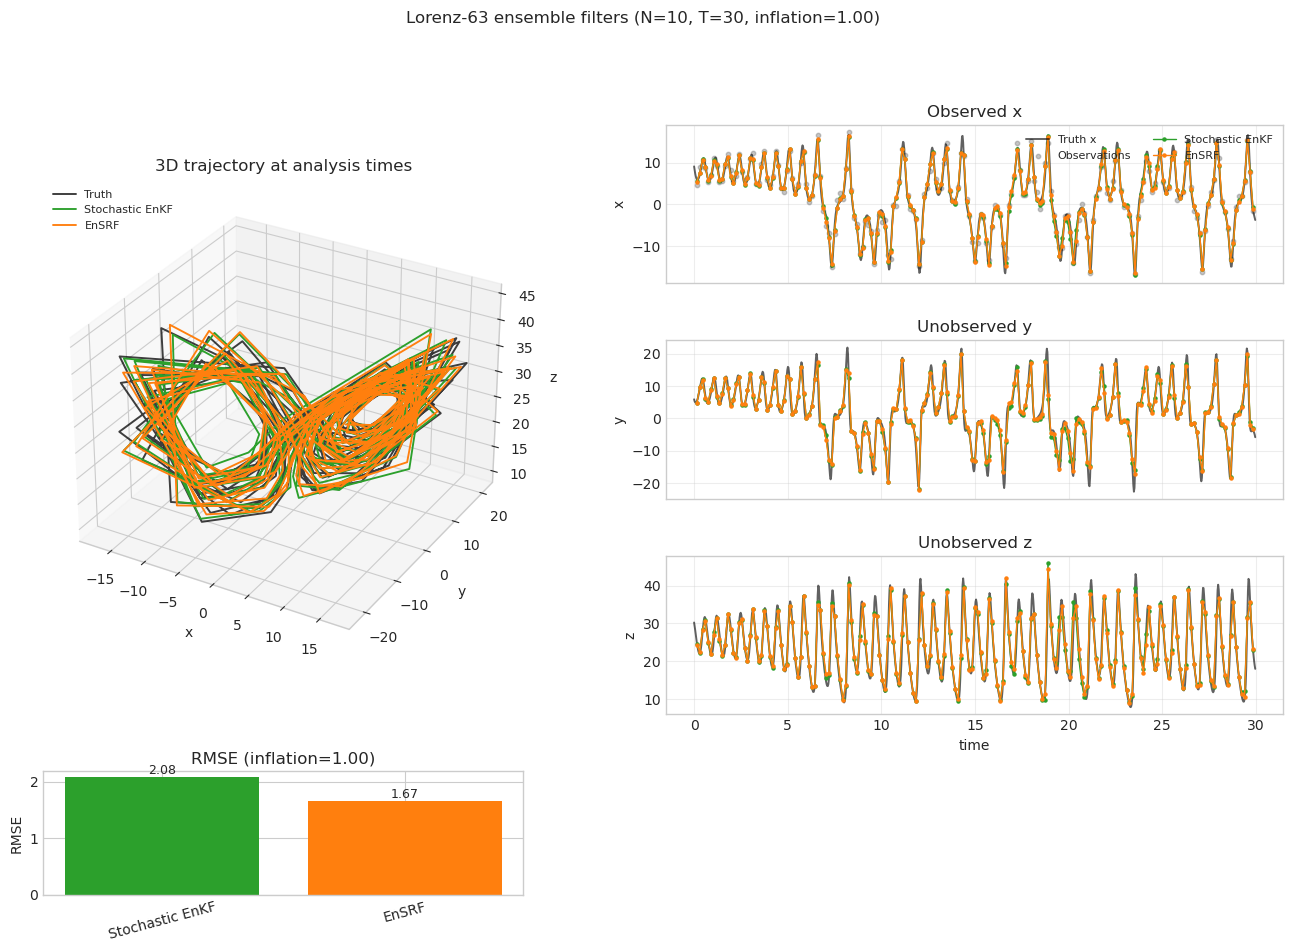

In [2]:
#@title Lorenz-63 ensemble-filter comparison
try:
    import torch
except ImportError:
    torch = None
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
np.set_printoptions(precision=4, suppress=True)

TORCH_AVAILABLE = torch is not None
TORCH_GPU_AVAILABLE = bool(TORCH_AVAILABLE and torch.cuda.is_available())
TORCH_DEVICE = torch.device("cuda") if TORCH_GPU_AVAILABLE else (torch.device("cpu") if TORCH_AVAILABLE else None)
TORCH_DTYPE = torch.float64 if TORCH_AVAILABLE else None


def as_torch(x, device=None, dtype=None):
    if not TORCH_AVAILABLE:
        raise RuntimeError("PyTorch is not available in this environment.")
    if device is None:
        device = TORCH_DEVICE
    if dtype is None:
        dtype = TORCH_DTYPE
    return torch.as_tensor(x, device=device, dtype=dtype)


def symmetrize_torch(M):
    return 0.5 * (M + M.T)


def mvn_sample_torch(mean, cov, size=None, generator=None, eps=1e-9):
    mean = as_torch(mean)
    cov = as_torch(cov, device=mean.device, dtype=mean.dtype)
    cov = symmetrize_torch(cov)
    w, V = torch.linalg.eigh(cov)
    w = torch.clamp(w, min=eps)
    sqrt_cov = (V * torch.sqrt(w)) @ V.T
    d = mean.shape[0]
    if size is None:
        z = torch.randn(d, device=mean.device, dtype=mean.dtype, generator=generator)
        return mean + sqrt_cov @ z
    z = torch.randn((size, d), device=mean.device, dtype=mean.dtype, generator=generator)
    return z @ sqrt_cov.T + mean


def gaussian_logpdf_torch(x, mean, cov):
    x = as_torch(x).reshape(-1)
    mean = as_torch(mean, device=x.device, dtype=x.dtype).reshape(-1)
    cov = as_torch(cov, device=x.device, dtype=x.dtype)
    cov = symmetrize_torch(cov)
    d = x.shape[0]
    xc = x - mean
    sign, logdet = torch.linalg.slogdet(cov)
    if sign.item() <= 0:
        cov = cov + 1e-9 * torch.eye(cov.shape[0], device=cov.device, dtype=cov.dtype)
        _, logdet = torch.linalg.slogdet(cov)
    quad = xc @ torch.linalg.pinv(cov) @ xc
    const = torch.log(torch.tensor(2.0 * np.pi, device=x.device, dtype=x.dtype))
    return -0.5 * (d * const + logdet + quad)


def gaussian_logpdf_batch_torch(x, means, cov):
    means = as_torch(means)
    x = as_torch(x, device=means.device, dtype=means.dtype).reshape(1, -1)
    cov = as_torch(cov, device=means.device, dtype=means.dtype)
    cov = symmetrize_torch(cov)

    d = means.shape[1]
    xc = means - x
    sign, logdet = torch.linalg.slogdet(cov)
    if sign.item() <= 0:
        cov = cov + 1e-9 * torch.eye(cov.shape[0], device=cov.device, dtype=cov.dtype)
        _, logdet = torch.linalg.slogdet(cov)
    cov_inv = torch.linalg.pinv(cov)
    quad = torch.sum((xc @ cov_inv) * xc, dim=1)
    const = torch.log(torch.tensor(2.0 * np.pi, device=means.device, dtype=means.dtype))
    return -0.5 * (d * const + logdet + quad)


def normalize_logweights_torch(logw):
    m = torch.max(logw)
    w = torch.exp(logw - m)
    s = torch.sum(w)
    if (not torch.isfinite(s).item()) or (s.item() <= 0):
        return torch.ones_like(logw) / logw.numel()
    return w / s


def systematic_resample_torch(weights, generator=None):
    n = weights.numel()
    u0 = torch.rand((), device=weights.device, dtype=weights.dtype, generator=generator)
    u = (u0 + torch.arange(n, device=weights.device, dtype=weights.dtype)) / n
    cdf = torch.cumsum(weights, dim=0)
    idx = torch.searchsorted(cdf, u, right=True)
    return torch.clamp(idx, 0, n - 1).long()


def lorenz63_rhs_torch(x, sigma=10.0, rho=28.0, beta=8.0 / 3.0):
    xx = x[..., 0]
    yy = x[..., 1]
    zz = x[..., 2]
    return torch.stack([
        sigma * (yy - xx),
        xx * (rho - zz) - yy,
        xx * yy - beta * zz,
    ], dim=-1)


def lorenz63_step_torch(x, dt=0.03):
    k1 = lorenz63_rhs_torch(x)
    k2 = lorenz63_rhs_torch(x + 0.5 * dt * k1)
    k3 = lorenz63_rhs_torch(x + 0.5 * dt * k2)
    k4 = lorenz63_rhs_torch(x + dt * k3)
    return x + (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)



def symmetrize(M):
    return 0.5 * (M + M.T)


def sqrtm_psd(M, eps=1e-12):
    w, V = np.linalg.eigh(symmetrize(M))
    w = np.clip(w, eps, None)
    return (V * np.sqrt(w)) @ V.T


def invsqrtm_psd(M, eps=1e-12):
    w, V = np.linalg.eigh(symmetrize(M))
    w = np.clip(w, eps, None)
    return (V * (1.0 / np.sqrt(w))) @ V.T


def gaussian_logpdf(x, mean, cov):
    x = np.atleast_1d(x)
    mean = np.atleast_1d(mean)
    cov = np.atleast_2d(cov)
    d = x.shape[0]
    xc = x - mean
    sign, logdet = np.linalg.slogdet(cov)
    if sign <= 0:
        cov = cov + 1e-9 * np.eye(cov.shape[0])
        sign, logdet = np.linalg.slogdet(cov)
    quad = xc @ np.linalg.pinv(cov) @ xc
    return -0.5 * (d * np.log(2.0 * np.pi) + logdet + quad)


def normalize_logweights(logw):
    m = np.max(logw)
    w = np.exp(logw - m)
    s = np.sum(w)
    if (not np.isfinite(s)) or s <= 0:
        return np.ones_like(logw) / len(logw)
    return w / s


def systematic_resample(weights, rng):
    n = len(weights)
    u = (rng.random() + np.arange(n)) / n
    cdf = np.cumsum(weights)
    idx = np.searchsorted(cdf, u, side="right")
    return np.clip(idx, 0, n - 1)


def make_rotation(theta):
    c, s = np.cos(theta), np.sin(theta)
    return np.array([[c, -s], [s, c]])


def sample_linear_initial(rng, d=2):
    m0 = rng.multivariate_normal(np.zeros(d), np.eye(d))
    v0 = rng.multivariate_normal(m0, np.eye(d))
    return v0, m0


def simulate_linear_gaussian_2d(T=80, theta=0.3, sigma_v=0.01, sigma_y=1.0, seed=0):
    rng = np.random.default_rng(seed)
    A = make_rotation(theta)
    H = np.array([[1.0, 0.0]])
    Sigma = (sigma_v ** 2) * np.eye(2)
    Gamma = np.array([[sigma_y ** 2]])

    truth = np.zeros((T, 2))
    obs = np.zeros((T, 1))

    v, _ = sample_linear_initial(rng, d=2)
    for k in range(T):
        v = A @ v + rng.multivariate_normal(np.zeros(2), Sigma)
        y = H @ v + rng.multivariate_normal(np.zeros(1), Gamma)
        truth[k] = v
        obs[k] = y

    return truth, obs, A, H, Sigma, Gamma


def lorenz63_rhs(x, sigma=10.0, rho=28.0, beta=8.0 / 3.0):
    xx, yy, zz = x
    return np.array([
        sigma * (yy - xx),
        xx * (rho - zz) - yy,
        xx * yy - beta * zz,
    ])


def lorenz63_step(x, dt=0.03):
    k1 = lorenz63_rhs(x)
    k2 = lorenz63_rhs(x + 0.5 * dt * k1)
    k3 = lorenz63_rhs(x + 0.5 * dt * k2)
    k4 = lorenz63_rhs(x + dt * k3)
    return x + (dt / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)


def lorenz63_burnin_initial(rng, dt=0.03, burn_steps=100):
    m0 = rng.multivariate_normal(np.zeros(3), np.eye(3))
    x = m0.copy()
    for _ in range(burn_steps):
        x = lorenz63_step(x, dt)
    x0 = x.copy()
    v0 = rng.multivariate_normal(x0, np.eye(3))
    return v0, m0, x0


def simulate_lorenz63(T=10.0, dt=0.03, Delta_t=0.15, sigma_v=0.01, sigma_y=1.0, burn_steps=100, seed=0):
    rng = np.random.default_rng(seed)
    n_steps = max(int(T / dt), 1)

    truth = np.zeros((n_steps, 3))
    x, _, _ = lorenz63_burnin_initial(rng, dt=dt, burn_steps=burn_steps)
    # Burn-in states are discarded; truth[0] is the first post-burn-in state.

    for t in range(n_steps):
        x = lorenz63_step(x, dt)
        if sigma_v > 0:
            x = x + rng.normal(0.0, sigma_v, size=3)
        truth[t] = x

    obs_gap = max(int(round(Delta_t / dt)), 1)
    obs_idx = [0]  # Observe first dimension only
    obs_times = np.arange(obs_gap, n_steps, obs_gap)
    Gamma = (sigma_y ** 2) * np.eye(len(obs_idx))
    obs = truth[obs_times][:, obs_idx] + rng.multivariate_normal(np.zeros(len(obs_idx)), Gamma, size=len(obs_times))

    return truth, obs, obs_times, obs_idx


def analysis_enkf_stochastic(Xf, y_obs, h_func, Gamma, rng):
    N = Xf.shape[0]
    Yf = np.array([h_func(x) for x in Xf])

    xbar = Xf.mean(axis=0)
    ybar = Yf.mean(axis=0)

    Xp = Xf - xbar
    Yp = Yf - ybar

    Pxy = (Xp.T @ Yp) / max(N - 1, 1)
    Pyy = (Yp.T @ Yp) / max(N - 1, 1) + Gamma

    K = Pxy @ np.linalg.pinv(Pyy)
    pert = rng.multivariate_normal(np.zeros(len(y_obs)), Gamma, size=N)

    Xa = Xf + (y_obs + pert - Yf) @ K.T
    return Xa


def analysis_ensrf(Xf, y_obs, h_func, gamma_diag):
    # Serial square-root update for (approximately) diagonal observation error covariance.
    X = Xf.copy()
    m_obs = len(y_obs)

    for ell in range(m_obs):
        Y = np.array([h_func(x) for x in X])
        y_f = Y[:, ell]

        x_mean = X.mean(axis=0)
        A = X - x_mean
        y_mean = np.mean(y_f)
        dy = y_f - y_mean

        r = max(float(gamma_diag[ell]), 1e-12)
        p_yy = (dy @ dy) / max(len(dy) - 1, 1) + r
        p_xy = (A.T @ dy) / max(len(dy) - 1, 1)

        K = p_xy / p_yy
        x_mean = x_mean + K * (y_obs[ell] - y_mean)

        alpha = 1.0 / (1.0 + np.sqrt(r / p_yy))
        K_tilde = alpha * K
        A = A - np.outer(dy, K_tilde)

        X = x_mean + A

    return X


def post_analysis_inflate(Xa, infl_rate):
    if np.isclose(infl_rate, 1.0):
        return Xa
    xbar = Xa.mean(axis=0, keepdims=True)
    return xbar + infl_rate * (Xa - xbar)


def analysis_enkf_stochastic_torch(Xf, y_obs, H, Gamma):
    N = Xf.shape[0]
    Yf = Xf @ H.T

    xbar = Xf.mean(dim=0)
    ybar = Yf.mean(dim=0)

    Xp = Xf - xbar
    Yp = Yf - ybar

    Pxy = (Xp.T @ Yp) / max(N - 1, 1)
    Pyy = (Yp.T @ Yp) / max(N - 1, 1) + Gamma

    K = Pxy @ torch.linalg.pinv(Pyy)
    pert = mvn_sample_torch(
        torch.zeros(y_obs.shape[0], device=Xf.device, dtype=Xf.dtype),
        Gamma,
        size=N,
    )
    Xa = Xf + (y_obs.unsqueeze(0) + pert - Yf) @ K.T
    return Xa


def analysis_ensrf_torch(Xf, y_obs, H, gamma_diag):
    X = Xf.clone()
    m_obs = y_obs.shape[0]

    for ell in range(m_obs):
        y_f = X @ H[ell]

        x_mean = X.mean(dim=0)
        A = X - x_mean
        y_mean = torch.mean(y_f)
        dy = y_f - y_mean

        r = torch.clamp(gamma_diag[ell], min=1e-12)
        p_yy = (dy @ dy) / max(len(dy) - 1, 1) + r
        p_xy = (A.T @ dy) / max(len(dy) - 1, 1)

        K = p_xy / p_yy
        x_mean = x_mean + K * (y_obs[ell] - y_mean)

        alpha = 1.0 / (1.0 + torch.sqrt(r / p_yy))
        K_tilde = alpha * K
        A = A - torch.outer(dy, K_tilde)
        X = x_mean + A

    return X


def post_analysis_inflate_torch(Xa, infl_rate):
    if np.isclose(infl_rate, 1.0):
        return Xa
    xbar = Xa.mean(dim=0, keepdim=True)
    return xbar + infl_rate * (Xa - xbar)


def run_ensemble_linear_torch(
    obs,
    A,
    H,
    Sigma,
    Gamma,
    N,
    method,
    use_true_init,
    truth_x0,
    inflation,
    seed,
    progress_bar=None,
):
    device = torch.device("cuda")
    torch.manual_seed(int(seed))
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(int(seed))

    obs_t = as_torch(obs, device=device, dtype=TORCH_DTYPE)
    A_t = as_torch(A, device=device, dtype=TORCH_DTYPE)
    H_t = as_torch(H, device=device, dtype=TORCH_DTYPE)
    Sigma_t = as_torch(Sigma, device=device, dtype=TORCH_DTYPE)
    Gamma_t = as_torch(Gamma, device=device, dtype=TORCH_DTYPE)
    truth_x0_t = as_torch(truth_x0, device=device, dtype=TORCH_DTYPE)

    T = obs_t.shape[0]
    d = A_t.shape[0]

    if use_true_init:
        X = mvn_sample_torch(truth_x0_t, torch.eye(d, device=device, dtype=TORCH_DTYPE), size=N)
    else:
        offset = torch.normal(mean=0.0, std=0.5, size=(d,), device=device, dtype=TORCH_DTYPE)
        X = mvn_sample_torch(truth_x0_t + offset, torch.eye(d, device=device, dtype=TORCH_DTYPE), size=N)

    est = torch.zeros((T, d), device=device, dtype=TORCH_DTYPE)
    zero_d = torch.zeros(d, device=device, dtype=TORCH_DTYPE)

    for k in range(T):
        X = X @ A_t.T + mvn_sample_torch(zero_d, Sigma_t, size=N)

        y = obs_t[k].reshape(-1)
        if method == "enkf":
            X = analysis_enkf_stochastic_torch(X, y, H_t, Gamma_t)
        elif method == "ensrf":
            X = analysis_ensrf_torch(X, y, H_t, torch.diag(Gamma_t))
        else:
            raise ValueError(f"Unknown ensemble method: {method}")

        X = post_analysis_inflate_torch(X, inflation)
        est[k] = X.mean(dim=0)

        if progress_bar:
            progress_bar.value += 1

    return est.detach().cpu().numpy()


def run_ensemble_lorenz_torch(
    obs,
    obs_times,
    obs_idx,
    dt,
    sigma_v,
    sigma_y,
    N,
    method,
    use_true_init,
    truth_x0,
    inflation,
    seed,
    progress_bar=None,
):
    device = torch.device("cuda")
    torch.manual_seed(int(seed))
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(int(seed))

    T_obs = len(obs)
    d = 3

    H_t = torch.zeros((len(obs_idx), d), device=device, dtype=TORCH_DTYPE)
    for r, c in enumerate(obs_idx):
        H_t[r, c] = 1.0

    Gamma_t = (sigma_y ** 2) * torch.eye(len(obs_idx), device=device, dtype=TORCH_DTYPE)
    truth_x0_t = as_torch(truth_x0, device=device, dtype=TORCH_DTYPE)

    if use_true_init:
        X = mvn_sample_torch(truth_x0_t, torch.eye(d, device=device, dtype=TORCH_DTYPE), size=N)
    else:
        offset = torch.normal(mean=0.0, std=2.0, size=(d,), device=device, dtype=TORCH_DTYPE)
        X = mvn_sample_torch(truth_x0_t + offset, torch.eye(d, device=device, dtype=TORCH_DTYPE), size=N)

    obs_t = as_torch(obs, device=device, dtype=TORCH_DTYPE)
    est = torch.zeros((T_obs, d), device=device, dtype=TORCH_DTYPE)
    current_time_step = 0

    for k in range(T_obs):
        target_time_step = int(obs_times[k])
        steps_to_sim = max(target_time_step - current_time_step, 0)

        for _ in range(steps_to_sim):
            X = lorenz63_step_torch(X, dt)
            if sigma_v > 0:
                X = X + sigma_v * torch.randn_like(X)

        y = obs_t[k].reshape(-1)
        if method == "enkf":
            X = analysis_enkf_stochastic_torch(X, y, H_t, Gamma_t)
        elif method == "ensrf":
            X = analysis_ensrf_torch(X, y, H_t, torch.diag(Gamma_t))
        else:
            raise ValueError(f"Unknown ensemble method: {method}")

        X = post_analysis_inflate_torch(X, inflation)
        est[k] = X.mean(dim=0)
        current_time_step = target_time_step

        if progress_bar:
            progress_bar.value += 1

    return est.detach().cpu().numpy()


def run_ensemble_linear(
    obs,
    A,
    H,
    Sigma,
    Gamma,
    N,
    method,
    use_true_init,
    truth_x0,
    inflation,
    seed,
    progress_bar=None,
):
    if TORCH_GPU_AVAILABLE:
        return run_ensemble_linear_torch(
            obs,
            A,
            H,
            Sigma,
            Gamma,
            N,
            method,
            use_true_init,
            truth_x0,
            inflation,
            seed,
            progress_bar=progress_bar,
        )

    rng = np.random.default_rng(seed)
    T = len(obs)
    d = A.shape[0]

    if use_true_init:
        X = rng.multivariate_normal(truth_x0, np.eye(d), size=N)
    else:
        offset = rng.normal(0.0, 0.5, size=d)
        X = rng.multivariate_normal(truth_x0 + offset, np.eye(d), size=N)

    est = np.zeros((T, d))

    def h_lin(x):
        return (H @ x).reshape(-1)

    for k in range(T):
        # Forecast
        X = X @ A.T + rng.multivariate_normal(np.zeros(d), Sigma, size=N)

        # Analysis
        y = obs[k].reshape(-1)
        if method == "enkf":
            X = analysis_enkf_stochastic(X, y, h_lin, Gamma, rng)
        elif method == "ensrf":
            X = analysis_ensrf(X, y, h_lin, np.diag(Gamma))
        else:
            raise ValueError(f"Unknown ensemble method: {method}")

        # Post-analysis inflation
        X = post_analysis_inflate(X, inflation)

        est[k] = X.mean(axis=0)

        if progress_bar:
            progress_bar.value += 1

    return est


def run_ensemble_lorenz(
    obs,
    obs_times,
    obs_idx,
    dt,
    sigma_v,
    sigma_y,
    N,
    method,
    use_true_init,
    truth_x0,
    inflation,
    seed,
    progress_bar=None,
):
    if TORCH_GPU_AVAILABLE:
        return run_ensemble_lorenz_torch(
            obs,
            obs_times,
            obs_idx,
            dt,
            sigma_v,
            sigma_y,
            N,
            method,
            use_true_init,
            truth_x0,
            inflation,
            seed,
            progress_bar=progress_bar,
        )

    rng = np.random.default_rng(seed)
    T_obs = len(obs)
    d = 3

    H = np.zeros((len(obs_idx), d))
    for r, c in enumerate(obs_idx):
        H[r, c] = 1.0

    Gamma = (sigma_y ** 2) * np.eye(len(obs_idx))

    if use_true_init:
        X = rng.multivariate_normal(truth_x0, np.eye(d), size=N)
    else:
        offset = rng.normal(0.0, 2.0, size=d)
        X = rng.multivariate_normal(truth_x0 + offset, np.eye(d), size=N)

    est = np.zeros((T_obs, d))
    current_time_step = 0

    def h_l63(x):
        return x[obs_idx]

    for k in range(T_obs):
        target_time_step = obs_times[k]
        steps_to_sim = target_time_step - current_time_step

        # Forecast
        for i in range(N):
            temp = X[i]
            for _ in range(steps_to_sim):
                temp = lorenz63_step(temp, dt)
                if sigma_v > 0:
                    temp += rng.normal(0.0, sigma_v, size=d)
            X[i] = temp

        # Analysis
        y = np.atleast_1d(obs[k])
        if method == "enkf":
            X = analysis_enkf_stochastic(X, y, h_l63, Gamma, rng)
        elif method == "ensrf":
            X = analysis_ensrf(X, y, h_l63, np.diag(Gamma))
        else:
            raise ValueError(f"Unknown ensemble method: {method}")

        # Post-analysis inflation
        X = post_analysis_inflate(X, inflation)

        est[k] = X.mean(axis=0)
        current_time_step = target_time_step

        if progress_bar:
            progress_bar.value += 1

    return est

DEFAULT_PARAMETERS = {
    "lorenz_ensemble_filter": {
        "total_time": 30.0,
        "dt": 0.03,
        "assimilation_time_step": 0.15,
        "dynamics_noise_std": 0.01,
        "observation_noise_std": 1.0,
        "ensemble_size": 10,
        "inflation": 1.0,
        "use_true_initialization": True,
        "burn_steps": 100,
        "seed": 99,
    },
}

use_default = False #@param {type:"boolean"}
ensemble_size = 10 #@param {type:"slider", min:5, max:100, step:5}
inflation = 1.0 #@param {type:"slider", min:1.0, max:1.3, step:0.01}
total_time = 30.0 #@param {type:"slider", min:5.0, max:30.0, step:5.0}
use_true_initialization = True #@param {type:"boolean"}

params = DEFAULT_PARAMETERS["lorenz_ensemble_filter"].copy()
if not use_default:
    params.update({
        "ensemble_size": int(ensemble_size),
        "inflation": float(inflation),
        "total_time": float(total_time),
        "use_true_initialization": bool(use_true_initialization),
    })

truth_full, obs, obs_times, obs_idx = simulate_lorenz63(
    T=params["total_time"],
    dt=params["dt"],
    Delta_t=params["assimilation_time_step"],
    sigma_v=params["dynamics_noise_std"],
    sigma_y=params["observation_noise_std"],
    burn_steps=params["burn_steps"],
    seed=params["seed"],
)
truth_at_obs = truth_full[obs_times]
methods = [
    ("Stochastic EnKF", "enkf", "tab:green"),
    ("EnSRF", "ensrf", "tab:orange"),
]

results = []
rmses = []
for name, method_code, color in methods:
    est = run_ensemble_lorenz(
        obs,
        obs_times,
        obs_idx,
        params["dt"],
        params["dynamics_noise_std"],
        params["observation_noise_std"],
        params["ensemble_size"],
        method_code,
        params["use_true_initialization"],
        truth_full[0],
        params["inflation"],
        seed=params["seed"] + 50,
    )
    rmse = np.sqrt(np.mean(np.sum((est - truth_at_obs) ** 2, axis=1)))
    results.append((name, est, color))
    rmses.append(rmse)

print("Effective parameters:")
for key, value in params.items():
    print(f"  {key}: {value}")
print("\nRMSE at observation times:")
for (name, _, _), rmse in zip(results, rmses):
    print(f"  {name}: {rmse:.3f}")

t_full = np.arange(len(truth_full)) * params["dt"]
t_obs = obs_times * params["dt"]
component_names = ["Observed x", "Unobserved y", "Unobserved z"]
component_symbols = ["x", "y", "z"]

fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(
    4,
    2,
    width_ratios=[1.05, 1.35],
    height_ratios=[1.0, 1.0, 1.0, 0.78],
    hspace=0.38,
    wspace=0.26,
)

ax3d = fig.add_subplot(gs[:3, 0], projection="3d")
ax3d.plot(truth_at_obs[:, 0], truth_at_obs[:, 1], truth_at_obs[:, 2], "k-", lw=1.4, alpha=0.75, label="Truth")
for name, est, color in results:
    ax3d.plot(est[:, 0], est[:, 1], est[:, 2], color=color, lw=1.35, label=name)
ax3d.set_title("3D trajectory at analysis times")
ax3d.set_xlabel("x")
ax3d.set_ylabel("y")
ax3d.set_zlabel("z")
ax3d.legend(loc="upper left", fontsize=8)

ax_rmse = fig.add_subplot(gs[3, 0])
bars = ax_rmse.bar([name for name, _, _ in results], rmses, color=[color for _, _, color in results])
ax_rmse.set_title(f"RMSE (inflation={params['inflation']:.2f})")
ax_rmse.set_ylabel("RMSE")
ax_rmse.tick_params(axis="x", labelrotation=15)
for bar in bars:
    height = bar.get_height()
    ax_rmse.text(bar.get_x() + bar.get_width() / 2, height, f"{height:.2f}", ha="center", va="bottom", fontsize=9)

traj_axes = [fig.add_subplot(gs[row, 1]) for row in range(3)]
for dim, ax in enumerate(traj_axes):
    ax.plot(t_full, truth_full[:, dim], "k-", lw=1.4, alpha=0.62, label=f"Truth {component_symbols[dim]}")
    if dim == 0:
        ax.scatter(t_obs, obs[:, 0], c="gray", s=10, alpha=0.45, label="Observations")
    for name, est, color in results:
        ax.plot(t_obs, est[:, dim], color=color, marker="o", markersize=2.2, lw=1.0, label=name)
    ax.set_title(component_names[dim])
    ax.set_ylabel(component_symbols[dim])
    ax.grid(True, alpha=0.35)
    if dim == 2:
        ax.set_xlabel("time")
    else:
        ax.tick_params(labelbottom=False)
    if dim == 0:
        ax.legend(loc="upper right", ncol=2, fontsize=8)

fig.suptitle(
    f"Lorenz-63 ensemble filters (N={params['ensemble_size']}, T={params['total_time']:.0f}, inflation={params['inflation']:.2f})",
    y=0.995,
)
plt.show()
